In [52]:
import pandas as pd
from matplotlib import pyplot as plt

fp = "/playpen/mufan/levi/tianlong-chen-lab/material-super-resolution/__exps__/p(z | X)/ablation-loss-fn/2024-11-28_13-52-41_z_log_test/results.csv"
df = pd.read_csv(fp)
df.head()

,global_train_step,global_val_step,epoch,train_loss,val_loss,z
0,0.0,NaN,0,18.199005,NaN,18.484497
1,1.0,NaN,0,15.319711,NaN,15.878296
2,2.0,NaN,0,14.148617,NaN,14.830017
3,3.0,NaN,0,8.101680,NaN,8.886719
4,4.0,NaN,0,3.908163,NaN,4.542542


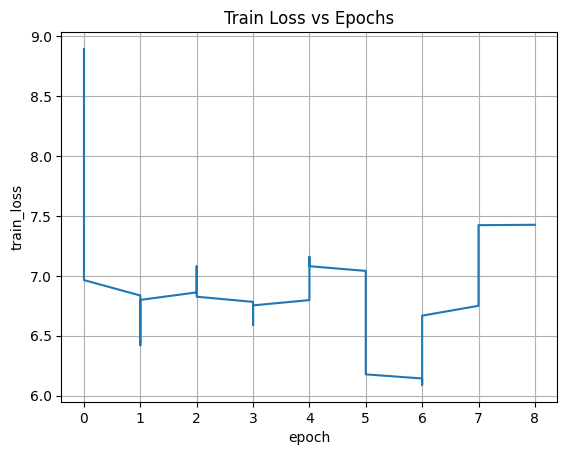

In [53]:
from scipy.ndimage import gaussian_filter1d

SIGMA = 10

_df = df[df["global_train_step"].notna()]
train_steps = _df["epoch"]
train_losses = _df["train_loss"]
train_losses_smoothed = gaussian_filter1d(train_losses, sigma=SIGMA)

# plt.plot(train_steps, train_losses)
plt.plot(train_steps, train_losses_smoothed)
plt.xlabel("epoch")
plt.ylabel("train_loss")
plt.title("Train Loss vs Epochs")
plt.grid()
plt.show()

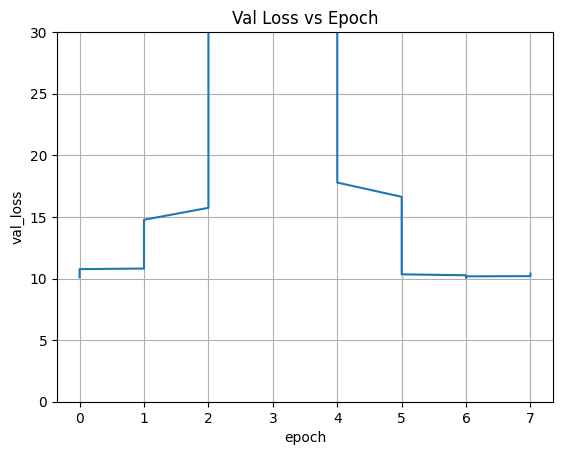

In [54]:
# plot val_loss vs. global_val_step
_df = df[df["global_val_step"].notna()]
val_steps = _df["epoch"]
val_losses = _df["val_loss"]
val_losses_smoothed = gaussian_filter1d(val_losses, sigma=SIGMA)

# plt.plot(val_steps, val_losses)
plt.plot(val_steps, val_losses_smoothed)
plt.xlabel("epoch")
plt.ylabel("val_loss")
plt.ylim(0, 30)
plt.title("Val Loss vs Epoch")
plt.grid()
plt.show()

In [55]:
_df["val_loss"][-10: ]

246     8.209523
247    11.037649
248    12.887999
249    10.608779
250     9.397555
251    11.951131
252     9.244194
253    10.963142
254     8.066148
255    12.717293
Name: val_loss, dtype: float64

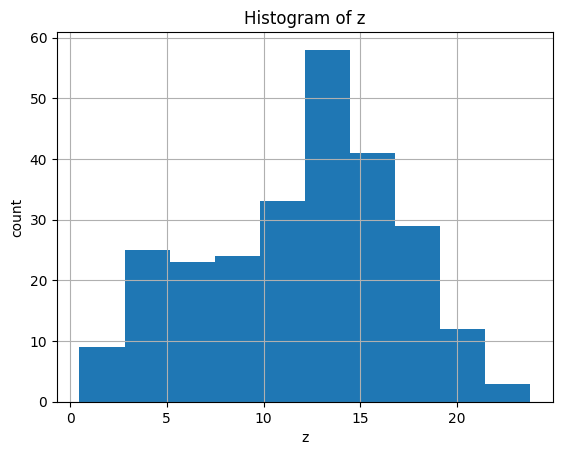

mean: 12.013636488858827
std: 4.975441869418187


In [56]:
zs = df['z']

# plot a histogram of z
plt.hist(zs)
plt.xlabel("z")
plt.ylabel("count")
plt.title("Histogram of z")
plt.grid()
plt.show()

# show on figure mean and std of zs
print(f"mean: {zs.mean()}")
print(f"std: {zs.std()}")